In [1]:
from pathlib import Path

from homm3.db import DataBase
from homm3.matches import RoundRobinMatch
from homm3.units import Unit, Stack, stack_count
from homm3.visual import draw_round_robin_results

In [2]:
# Select units from database

units_df = DataBase.find_units(tiers=3, grades=1, exclude_source_names="vcmi", order_by="name")
units_names = units_df["name"].tolist()
print(f"Selected {len(units_names)} units:\n{units_names}")

Selected 12 units:
['Bellwether Armadillo', 'Cerberus', 'Corsair', 'Dragon Fly', 'Evil Eye', 'Grand Elf', 'Ice Elemental', 'Iron Golem', 'Orc Chieftain', 'Royal Griffin', 'Steel Elf', 'Wraith']


In [3]:
# Forming stacks

count_method = "gold10k"
units = [Unit.from_db(name) for name in units_names]
stacks = [Stack(unit, count=stack_count(unit, count_method)) for unit in units]

In [5]:
# Run match

match_path = Path("../results/test_match.json")
n_runs = 50
seed = 42

match = RoundRobinMatch(stacks=stacks)
results = match.run(match_path, n_runs=n_runs, seed=seed, show_progress=True)

Wraith vs Steel Elf: 100%|██████████| 6600/6600 [01:04<00:00, 101.73it/s]                  


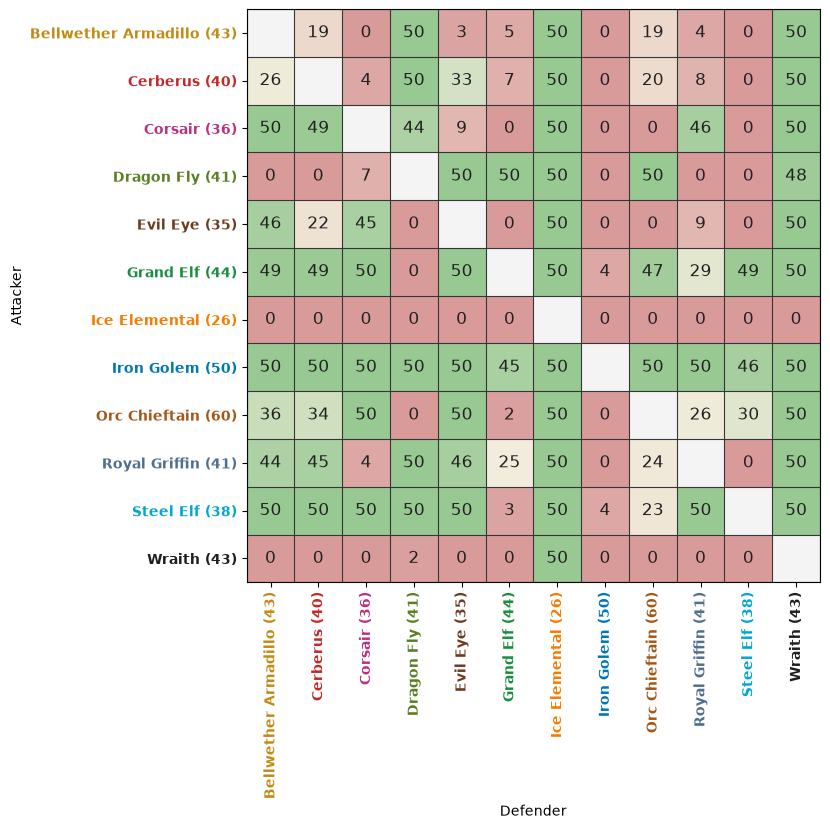

(<Figure size 960x840 with 1 Axes>,
 <Axes: xlabel='Defender', ylabel='Attacker'>)

In [2]:
# Draw result matrix

draw_round_robin_results(match_path, output_path=match_path.parent / "result_matrix.png", show=True)